<a href="https://colab.research.google.com/github/laramutair/Prediction-of-Product-Sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Project Title: (sales prediction).
- Author: Lara Mutair

## Project Overview part1 & part2

**Part 1**

This is an overview of the steps you will need to complete for part one of the project. There are more detailed instructions for each section following the overview.

Create a GitHub Account

Set up a GitHub repository that will house your first portfolio project.

Add Markdown cells with your name and section headers to the notebook.

Add the Google Colab Notebook to your GitHub repository.

Submit the link to your GitHub repo!


**Part 2**

We will continue to work off of the GitHub repository you created last week for your first portfolio project. The goal of your portfolio projects are to have items to show potential employers that demonstrate your data science skills and competencies.

The first project will be a sales prediction for food items sold at various stores. The goal of this is to help the retailer understand the properties of products and outlets that play crucial roles in increasing sales.

For Part 2, your task is to use Pandas to load in the data and start exploring and cleaning it.

- Download the data using this link: [download the data](https://drive.google.com/file/d/1syH81TVrbBsdymLT_jl2JIf6IjPXtSQw/view).
- Insert code below the heading "Loading Data"
  - Use Pandas to read the sales prediction data set into Google Colab.
  - Use df.info() and df.head() methods to preview the first rows of your data and a summary of your DataFrame's columns.
- Insert code below the heading "Data Cleaning"
   - Explore the data - what do you need to do to clean this data? Clean it!
   - Be sure to address each of the following tasks:

   
1) How many rows and columns?

2) What are the datatypes of each variable?

3) Are there duplicates? If so, drop any duplicates.

4) Identify missing values.

5) Address the missing values by using a placeholder value.

6) Confirm that there are no missing values after addressing them.

7) Find and fix any inconsistent categories of data (for example: fix cat, Cat, and cats so that they are consistent).

8) For any numerical columns, obtain the summary statistics of each (min, max, mean).


**Features:**

| Feature | Description |
|---------|-------------|
| `Item_Identifier` | Unique ID for each product |
| `Item_Weight` | Weight of the product |
| `Item_Fat_Content` | Type of fat content (Low Fat / Regular) |
| `Item_Visibility` | Percentage of display area allocated to the product in the store |
| `Item_Type` | Product category |
| `Item_MRP` | Maximum Retail Price of the product |
| `Outlet_Identifier` | Unique ID for each store |
| `Outlet_Establishment_Year` | Year the store was established |
| `Outlet_Size` | Physical size of the store |
| `Outlet_Location_Type` | Type of area where the store is located (Tier 1/2/3) |
| `Outlet_Type` | Type of retail store (Supermarket / Grocery Store) |
| `Item_Outlet_Sales` | Target variable: sales of the product in that outlet |



## EDA Functions

In [11]:
"""UNIVARIATE PLOTTING FUNCTIONS FOR EDA"""
def explore_numeric(df, x, figsize=(6,5)):

  #Save null values count for printing
  null_count = df[x].isna().sum()
  null_perc = null_count/len(df)*100

  #Making our figure
  gridspec = {'height_ratios':[0.7,0.3]}
  fig,axes = plt.subplots(nrows=2, figsize=figsize, sharex=True, gridspec_kw=gridspec)

  #Histogram
  sns.histplot(data=df, x=x, ax=axes[0])

  #Boxplot
  sns.boxplot(data=df, x=x, ax=axes[1])

  #Adding a tittle
  axes[0].set_title(f"Column: {x}", fontweight='bold')
  # Adjusting subplots to best fill Figure
  fig.tight_layout()

   # Ensure plot is shown before message
  plt.show()

  #Print null value info
  print(f"The NaN's count: {null_count}({round(null_perc, 2)}%)")

  #Print cardinality info
  nunique = df[x].nunique()
  print(f"Unique Values: {nunique}")

  # Get the most most common value, its count as # and as %
  most_common_val_count = df[x].value_counts(dropna=False).head(1)
  most_common_val = most_common_val_count.index[0]
  freq = most_common_val_count.values[0]
  perc_most_common = freq / len(df) * 100

  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")

  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
     print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
     print("- Not constant or quasi-constant.")

  # Make sure the plot is shown before the print statement
  plt.show()

  return fig, axes



def explore_categorical(df, x, fillna= True, placeholder='Missing', figsize=(6,4), order=None):

    #Make a copy of the data frame
    temp_df=df.copy()

    #Save null values and perc
    null_count = temp_df[x].isna().sum()
    null_perc = null_count/len(temp_df)*100

    #fillna with place holder
    if fillna == True:
      temp_df[x] = temp_df[x].fillna(placeholder)

    #Create figer
    fig,ax =plt.subplots(figsize=figsize)
    sns.countplot(data=temp_df, x=x , ax=ax , order=order)
    # Rotate Tick Labels for long names
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    # Add a title with the feature name included
    ax.set_title(f"Column: {x}", fontweight='bold')

    # Fix layout and show plot (before print statements)
    fig.tight_layout()
    plt.show()

    # Print null value info
    print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
    # Print cardinality info
    nunique = temp_df[x].nunique()
    print(f"- Unique Values: {nunique}")
    # First find value counts of feature
    val_counts = temp_df[x].value_counts(dropna=False)
    # Define the most common value
    most_common_val = val_counts.index[0]
    # Define the frequency of the most common value
    freq = val_counts.values[0]
    # Calculate the percentage of the most common value
    perc_most_common = freq / len(temp_df) * 100
    # Print the results
    print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")
    # print message if quasi-constant or constant (most common val more than 98% of data)
    if perc_most_common > 98:
      print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
    else:
      print("- Not constant or quasi-constant.")

    # Make sure the plot is shown before the print statement
    plt.show()
    return fig, ax



In [12]:
def categorical_vs_target(df, x, y='Item_Outlet_Sales', figsize=(6,4), fillna=True, placeholder='Missing', order=None ):
  #Make a copy of the dataframe and fillna
  temp_df=df.copy()

  #fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  else:
    temp_df = temp_df.dropna(subset=[x])

  #Create the figure and subplots
  fig, ax =plt.subplots(figsize=figsize)

  #Barplot
  sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
              linewidth=1, edgecolor='black', errorbar=None)

  #stripplot
  sns.stripplot(data=df, x=x, y=y, ax=ax, order=order , legend=False, edgecolor='white',
                hue_order=order, linewidth= 0.5, size=3, zorder=0)

  # Rotate xlabels
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

  # Add a title
  ax.set_title(f"{x} vs. {y}", fontweight='bold')
  fig.tight_layout()

  # Make sure the plot is shown before the print statement
  plt.show()
  return fig, ax


def plot_numeric_vs_target(df, x, y='Item_Outlet_Sales',
                           figsize=(6,4)):

  # Calculate the correlation
  corr = df[[x,y]].corr().round(2)
  r = corr.loc[x,y]

  # Plot the data
  fig, ax = plt.subplots(figsize=figsize)
  scatter_kws={'ec':'white','linewidths':1,'alpha':0.8}
  sns.regplot(data=df, x=x, y=y, ax=ax, scatter_kws=scatter_kws)

  ## Add the title with the correlation
  ax.set_title(f"{x} vs. {y} (r = {r})", fontweight='bold')

  # Make sure the plot is shown before the print statement
  plt.show()

  return fig, ax



## **Import and Load Data**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
path = '/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv'
df = pd.read_csv(path)
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [4]:
#number of columns and rows
df.shape

(8523, 12)

In [5]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


### Missing Values
Checking for Missing data:

In [6]:
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [7]:
df.isna().sum()/len(df)*100

,0
Item_Identifier,0.000000
Item_Weight,17.165317
Item_Fat_Content,0.000000
Item_Visibility,0.000000
Item_Type,0.000000
Item_MRP,0.000000
Outlet_Identifier,0.000000
Outlet_Establishment_Year,0.000000
Outlet_Size,28.276428
Outlet_Location_Type,0.000000


## **Inspecting Each Feature**


### Feature Name: {Item_Weight}
  - Item_Weight: Weight of the product

In [9]:
feature= 'Item_Weight'
df[feature].dtype

dtype('float64')

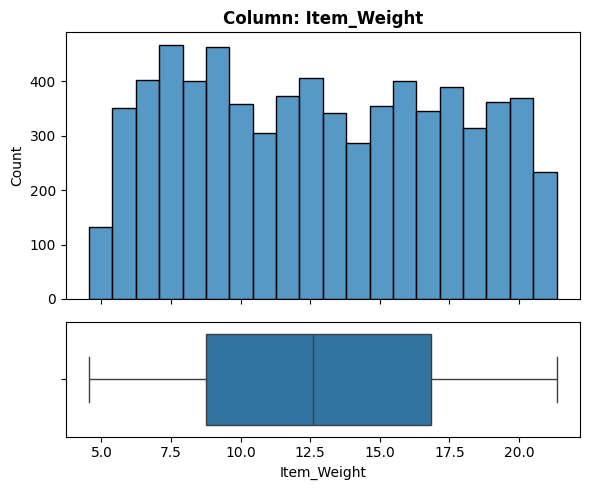

The NaN's count: 1463(17.17%)
Unique Values: 415
- Most common value: 'nan' occurs 1463 times (17.17%)
- Not constant or quasi-constant.


In [10]:
fig , ax =explore_numeric(df,feature )

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
    - Numeric

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
    - 1463 null values (17.17%)
    - Impute with Mean or Median.

3. Is the feature constant or quasi-constant?
    - No.

4. What is the cardinality? Is it high?
    - 415 unique categories.
    -  high

5. Would we know this BEFORE the target is determined?
    - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
    - No


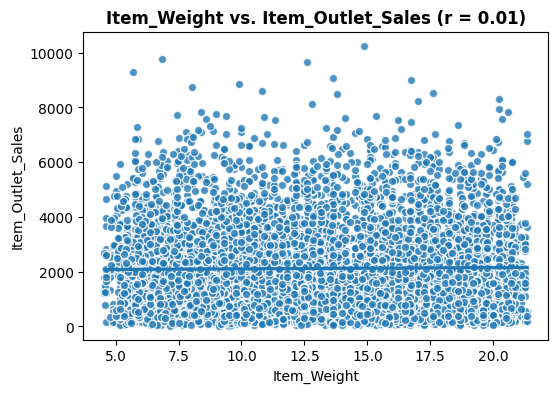

In [11]:
fig,ax=plot_numeric_vs_target(df,feature)

 Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - No, I would expect the weight of the item does not affect to the sales of this item
  - Does this feature appear to be a predictor of the target?
    - No it doesn't


### Feature Name: {Item_Fat_Content}
 - Item_Fat_Content: Type of fat content (Low Fat / Regular)

In [12]:
feature = 'Item_Fat_Content'
df[feature].dtype

dtype('O')

/tmp/ipykernel_5799/1996029582.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


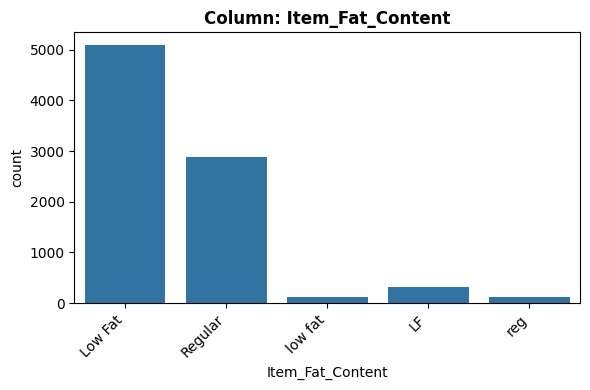

- NaN's Found: 0 (0.0%)
- Unique Values: 5
- Most common value: 'Low Fat' occurs 5089 times (59.71%)
- Not constant or quasi-constant.


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Column: Item_Fat_Content'}, xlabel='Item_Fat_Content', ylabel='count'>)

In [13]:
explore_categorical(df,feature)

In [14]:
#In fat_content we have inconsistent values
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({'Regular': 'Reg'
,'reg':'Reg'
,'low fat':'LF'
,'Low Fat':'LF'
})

/tmp/ipykernel_5799/1996029582.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


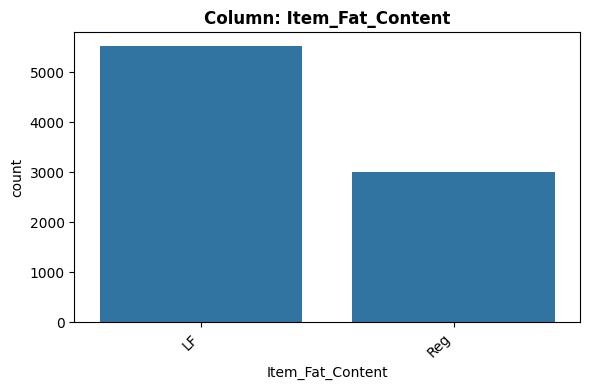

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'LF' occurs 5517 times (64.73%)
- Not constant or quasi-constant.


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Column: Item_Fat_Content'}, xlabel='Item_Fat_Content', ylabel='count'>)

In [15]:
explore_categorical(df,feature)

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
    - Categorical(nominal)

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
    - There is no missing values

3. Is the feature constant or quasi-constant?
    - No.

4. What is the cardinality? Is it high?
    - 2 (Low)
    

5. Would we know this BEFORE the target is determined?
    - Yes

6. Is there a business case/understanding reason to exclude based on our business case?
    - NO

/tmp/ipykernel_5799/495336852.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


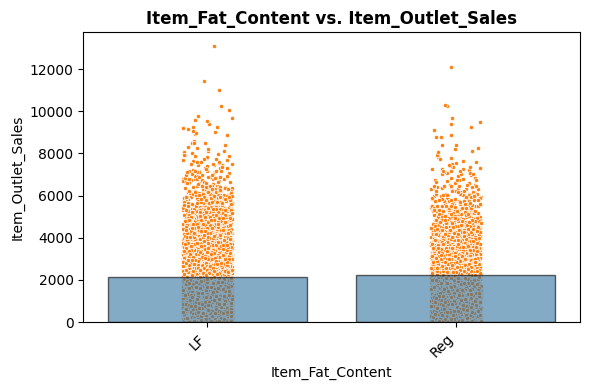

In [16]:
categorical_vs_target(df, feature);

 Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes, I would expect the LF has higher sales than Reg
  - Does this feature appear to be a predictor of the target?
    - Yes, weak predictor because the both of category have the same mean approximitly

### Feature Name: {Item_Visibility}
 - Item_Visibility: Percentage of display area allocated to the product in the store

In [17]:
feature = 'Item_Visibility'
df[feature].dtype

dtype('float64')

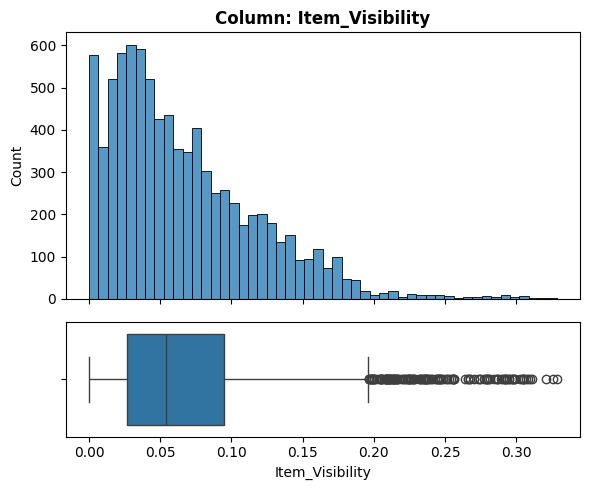

The NaN's count: 0(0.0%)
Unique Values: 7880
- Most common value: '0.0' occurs 526 times (6.17%)
- Not constant or quasi-constant.


(<Figure size 600x500 with 2 Axes>,
 array([<Axes: title={'center': 'Column: Item_Visibility'}, xlabel='Item_Visibility', ylabel='Count'>,
        <Axes: xlabel='Item_Visibility'>], dtype=object))

In [18]:
explore_numeric(df,feature)

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
    - Numeric

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
    - There is no missing values

3. Is the feature constant or quasi-constant?
    - No.

4. What is the cardinality? Is it high?
    - Not applicable (numeric)
    

5. Would we know this BEFORE the target is determined?
    - Yes

6. Is there a business case/understanding reason to exclude based on our business case?
    - No

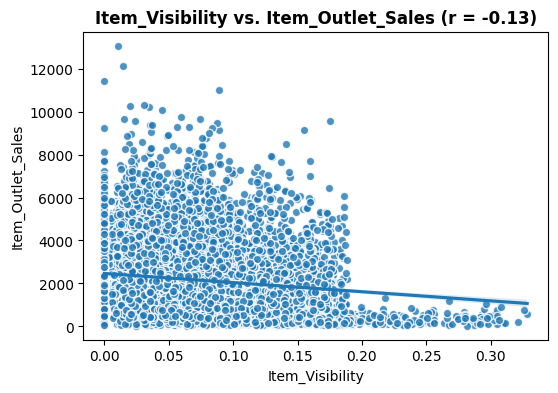

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_Visibility vs. Item_Outlet_Sales (r = -0.13)'}, xlabel='Item_Visibility', ylabel='Item_Outlet_Sales'>)

In [19]:
plot_numeric_vs_target(df,feature)

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes, I assume the item with high visiabilty has a higher sales
  - Does this feature appear to be a predictor of the target?
    - Yes, the feature appears to be a predictor of the target, but the relationship is negative rather than positive as initially expected.

###Feature Name: {Item_Type}
 - Item_Type:	Product category

In [20]:
feature = 'Item_Type'
df[feature].dtype

dtype('O')

/tmp/ipykernel_5799/1996029582.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


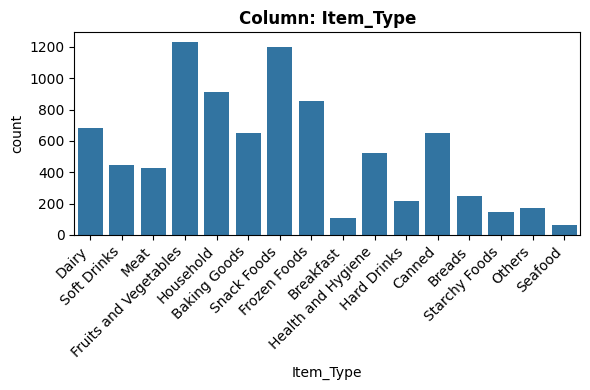

- NaN's Found: 0 (0.0%)
- Unique Values: 16
- Most common value: 'Fruits and Vegetables' occurs 1232 times (14.46%)
- Not constant or quasi-constant.


In [21]:
explore_categorical(df,feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
    - Categorical (nominal)

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
    - There is no missing values

3. Is the feature constant or quasi-constant?
    - No.

4. What is the cardinality? Is it high?
    - 16 (High)
    

5. Would we know this BEFORE the target is determined?
    - Yes

6. Is there a business case/understanding reason to exclude based on our business case?
    - No

/tmp/ipykernel_5799/495336852.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


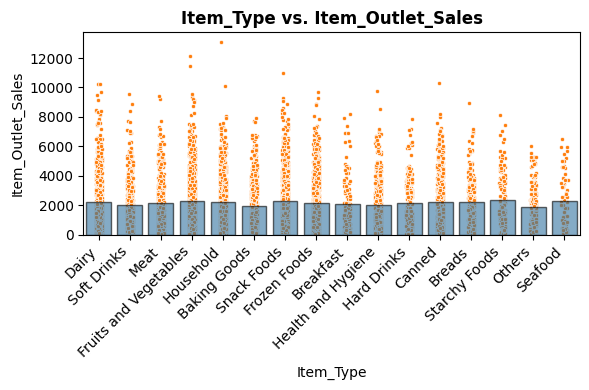

In [22]:
categorical_vs_target(df, feature);

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes, I assume some of product type has a higher sales than others
  - Does this feature appear to be a predictor of the target?
    - Yes, weak predictor

###Feature Name: {Item_MRP}
   - Item_MRP: Maximum Retail Price of the product  

In [9]:
feature = 'Item_MRP'
df[feature].dtype

dtype('float64')

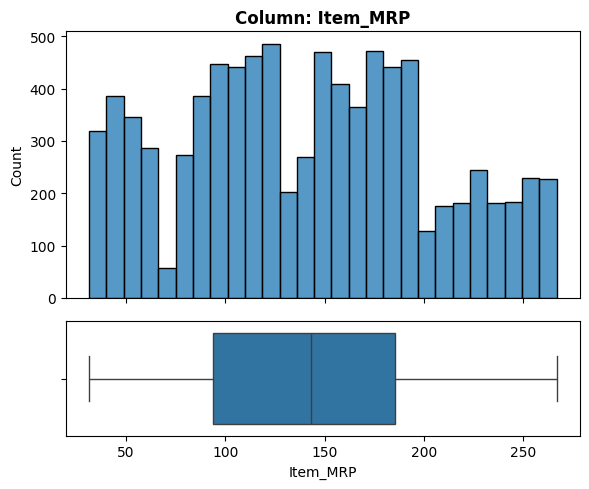

The NaN's count: 0(0.0%)
Unique Values: 5938
- Most common value: '172.0422' occurs 7 times (0.08%)
- Not constant or quasi-constant.


In [13]:
explore_numeric(df,feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
    - Numeric

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
    - There is no missing values

3. Is the feature constant or quasi-constant?
    - No.

4. What is the cardinality? Is it high?
    - Not applicable (numeric).
    

5. Would we know this BEFORE the target is determined?
    - Yes

6. Is there a business case/understanding reason to exclude based on our business case?
    - No

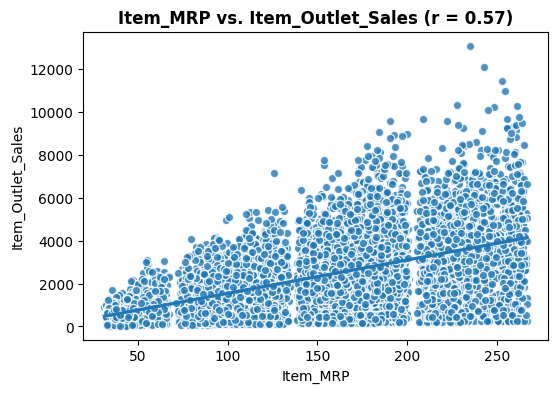

In [14]:
plot_numeric_vs_target(df, feature);

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes, I assume that sales are higher for items with lower prices
  - Does this feature appear to be a predictor of the target?
    - Yes, strong predictor. The plot clearly shows that as Item_MRP increases, Item_Outlet_Sales also increases. The regression line has a positive slope, items with higher MRP have higher sales.

###Feature Name: {Outlet_Est_Year}
   - Outlet_Establishment_Year:	Year the store was established

In [15]:
feature = 'Outlet_Establishment_Year'
df[feature].dtype

dtype('int64')

/tmp/ipykernel_17263/1996029582.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


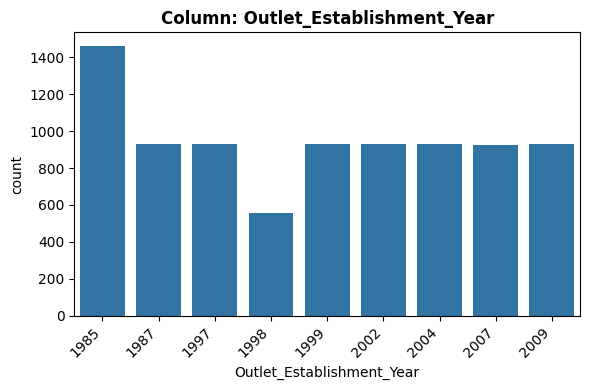

- NaN's Found: 0 (0.0%)
- Unique Values: 9
- Most common value: '1985' occurs 1463 times (17.17%)
- Not constant or quasi-constant.


In [16]:
explore_categorical(df,feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
    - Categorical (ordinal)

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
    - There is no missing values

3. Is the feature constant or quasi-constant?
    - No.

4. What is the cardinality? Is it high?
    - 9

5. Would we know this BEFORE the target is determined?
    - Yes

6. Is there a business case/understanding reason to exclude based on our business case?
    - No

/tmp/ipykernel_17263/495336852.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


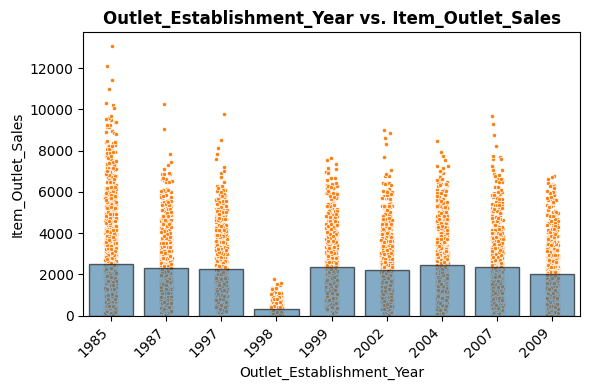

In [17]:
categorical_vs_target(df, feature);

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes, I assume that older stores are likely more trusted and well-known by customers, so we might expect them to have higher sales.
  - Does this feature appear to be a predictor of the target?
    - looking at the plot, most bars are at a similar height (around 2000-2500), which means sales are roughly the same across most years. The only exception is 1998, which looks very low

###Feature Name: {Outlet_Size}
   - Outlet_Size:Physical size of the store

In [23]:
feature = 'Outlet_Size'
orderSize = ['Small','Medium','High']
df[feature].dtype

dtype('O')

/tmp/ipykernel_5799/1996029582.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


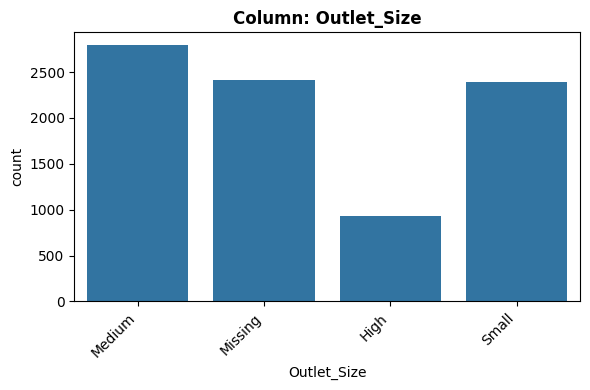

- NaN's Found: 2410 (28.28%)
- Unique Values: 4
- Most common value: 'Medium' occurs 2793 times (32.77%)
- Not constant or quasi-constant.


In [24]:
explore_categorical(df,feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
    - Categorical (nominal)

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
    - 2410 null values(28.28%)

3. Is the feature constant or quasi-constant?
    - No.

4. What is the cardinality? Is it high?
    - 3 low

5. Would we know this BEFORE the target is determined?
    - Yes

6. Is there a business case/understanding reason to exclude based on our business case?
    - No

/tmp/ipykernel_5799/495336852.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


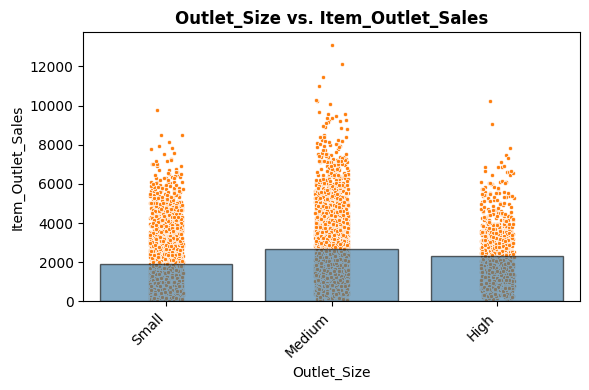

In [25]:
categorical_vs_target(df, feature, order=orderSize);

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes, it makes sense that larger stores would have more products on display and attract more customers, so we would expect higher sales in bigger outlets.
  - Does this feature appear to be a predictor of the target?
    - Yes, but a weak predictor. looking at the plot, there is a small difference between the groups. High and Medium stores have a slightly higher average sales bar compared to Small stores. However, the difference is not very large, so this feature may have some effect but it is not a strong predictor on its own.

###Feature Name: {Outlet_Location_Type}
   - Outlet_Location_Type:Type of area where the store is located (Tier 1/2/3)

In [18]:
feature = 'Outlet_Location_Type'
df[feature].dtype

dtype('O')

/tmp/ipykernel_5799/1996029582.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


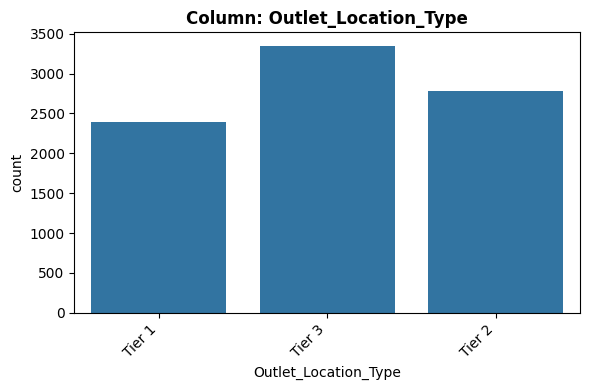

- NaN's Found: 0 (0.0%)
- Unique Values: 3
- Most common value: 'Tier 3' occurs 3350 times (39.31%)
- Not constant or quasi-constant.


In [27]:
explore_categorical(df,feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
    - Categorical (nominal)

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
    - There is no missing values

3. Is the feature constant or quasi-constant?
    - No.

4. What is the cardinality? Is it high?
    - 3 low

5. Would we know this BEFORE the target is determined?
    - Yes

6. Is there a business case/understanding reason to exclude based on our business case?
    - No

/tmp/ipykernel_5799/495336852.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


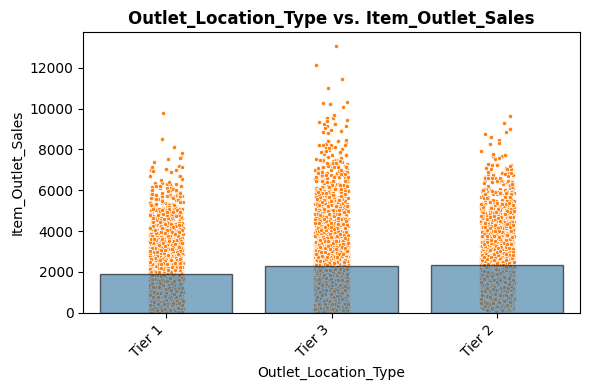

In [28]:
categorical_vs_target(df, feature);

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes, I expect that the store's location will have an impact on its sales.
  - Does this feature appear to be a predictor of the target?
    - Yes, weak predictor. looking at the plot, stores in Tier 2 have slightly higher sales than stores in other areas. However, the difference is not very large, so this feature may have some effect but it is not a strong predictor on its own.

###Feature Name: {Outlet_Type}
   - Outlet_Type: Type of retail store (Supermarket / Grocery Store)

In [29]:
feature = 'Outlet_Type'
df[feature].dtype

dtype('O')

/tmp/ipykernel_5799/1996029582.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


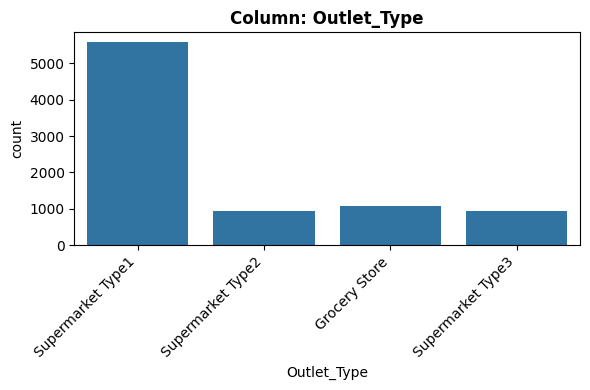

- NaN's Found: 0 (0.0%)
- Unique Values: 4
- Most common value: 'Supermarket Type1' occurs 5577 times (65.43%)
- Not constant or quasi-constant.


In [30]:
explore_categorical(df,feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
    - Categorical (nominal)

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
    - There is no missing values

3. Is the feature constant or quasi-constant?
    - No.

4. What is the cardinality? Is it high?
    - 4 low

5. Would we know this BEFORE the target is determined?
    - Yes

6. Is there a business case/understanding reason to exclude based on our business case?
    - No

/tmp/ipykernel_5799/495336852.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


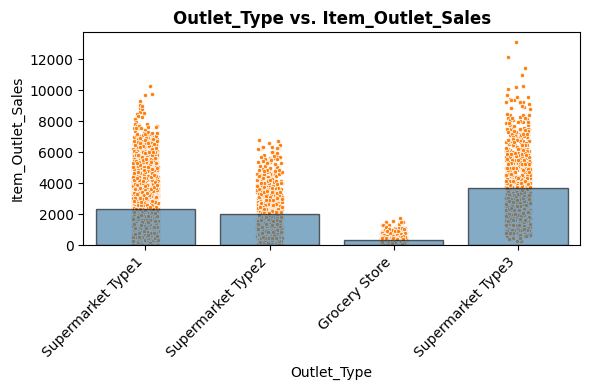

In [31]:
categorical_vs_target(df, feature);

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes, I assume that older stores are likely more trusted and well-known by customers, so we might expect them to have higher sales.
  - Does this feature appear to be a predictor of the target?
    - Yes, and it is a strong predictor, the plot shows a very clear difference between the store types:

        - Supermarket Type3 has by far the highest average sales (bar around 3800)

         - Supermarket Type1 and Type2 are in the middle (around 2000-2200)

        - Grocery Store has the lowest sales by a large margin (bar close to 0)


###Feature Name: {Item_Outlet_Sales}
   - Item_Outlet_Sales:Target variable: sales of the product in that outlet

In [19]:
feature = 'Item_Outlet_Sales'
df[feature].dtype

dtype('float64')

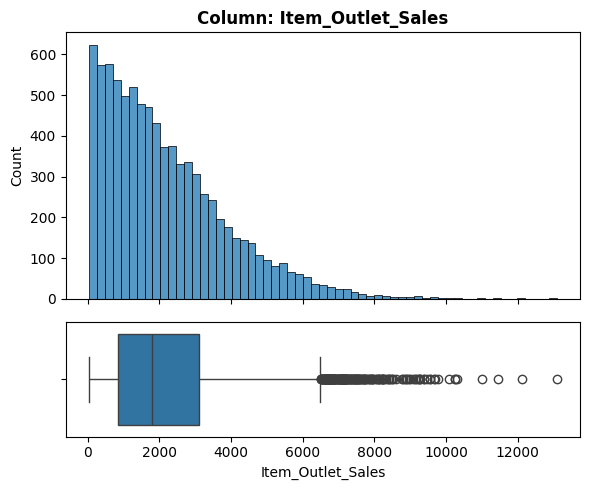

The NaN's count: 0(0.0%)
Unique Values: 3493
- Most common value: '958.752' occurs 17 times (0.2%)
- Not constant or quasi-constant.


In [20]:
explore_numeric(df,feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
    - Numeric

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
    -  There is no missing values

3. Is the feature constant or quasi-constant?
    - No.

4. What is the cardinality? Is it high?
    - ...

5. Would we know this BEFORE the target is determined?
    - ...

6. Is there a business case/understanding reason to exclude based on our business case?
    - No

### Handle Missing Data

In [ ]:
#Fill the missing value in Item_Weight by mean
#df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())

In [ ]:
#Fill the missing value in Outlet_Size by'MISSING'
#df['Outlet_Size'] = df['Outlet_Size'].fillna('MISSING')

###Duplicated Data
Checking for duplicated data:

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df[df.duplicated()]
#NO DUPLICATES

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales


###Checking and Fixing Consistency

In [ ]:
obj_column = df.select_dtypes(include='object')
obj_column.head()

In [ ]:
for col in obj_column:
  print(df[col].value_counts())
  print('-----------')

###  For any numerical columns, obtain the summary statistics of each (min, max, mean).

In [ ]:
num_col = df.select_dtypes('number')
num_col.head()

In [ ]:
num_col.describe()

###Multivariate Visualization

In [5]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


/tmp/ipykernel_17263/2210214670.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right");


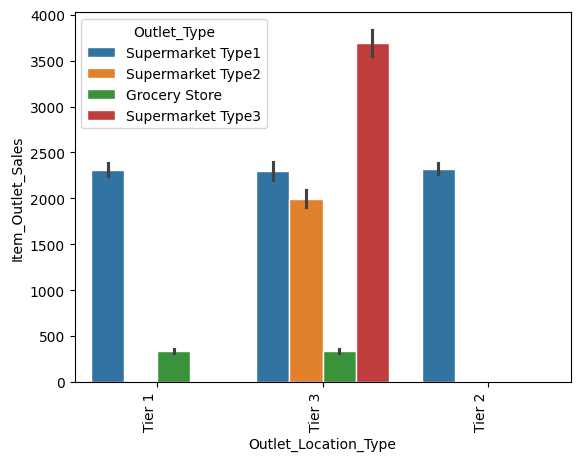

In [21]:
ax = sns.barplot(data=df, x='Outlet_Location_Type' , y='Item_Outlet_Sales' ,hue='Outlet_Type' , edgecolor='white', linewidth=1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right");

- What I noticed in this plot ?

    - Supermarket Type3 int Tier 3 area has the highest sales across all location types, while Grocery Store has the lowest sales in all locations

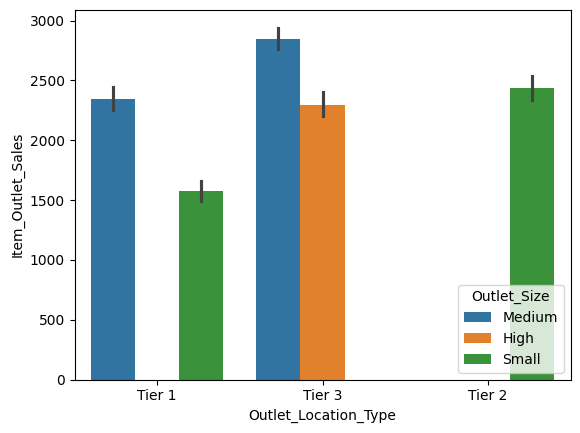

In [25]:
sns.barplot(data=df , x='Outlet_Location_Type', y='Item_Outlet_Sales' , hue='Outlet_Size');

<Axes: >

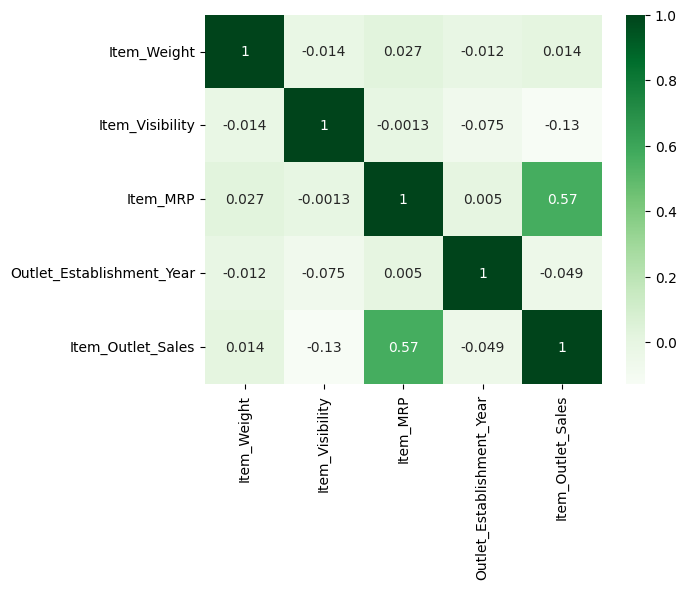

In [23]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr,cmap='Greens' ,annot=True)